# Aprendizado por Reforço — Cliff Walking

O **Aprendizado por Reforço (RL)** é um paradigma de aprendizado de máquina em que um **agente** aprende a se comportar em um **ambiente** através de **interação** e **recompensas**. Diferente do MDP com programação dinâmica, o agente não conhece as probabilidades de transição — ele aprende apenas pela experiência.

## Definição Formal

O problema de RL envolve:

| Componente | Descrição |
|---|---|
| **S** | Conjunto de estados do ambiente |
| **A** | Conjunto de ações disponíveis |
| **r(s, a, s')** | Recompensa observada ao transitar de s para s' via a |
| **γ ∈ (0,1]** | Fator de desconto (valorização de recompensas futuras) |
| **π : S → A** | Política que o agente aprende |

## Diferença entre MDP e RL

| | MDP (Prog. Dinâmica) | Aprendizado por Reforço |
|---|---|---|
| **Transições T(s,a,s')** | Conhecidas | Desconhecidas |
| **Como aprende** | Resolve equações de Bellman | Interage com o ambiente |
| **Algoritmos** | Value Iteration, Policy Iteration | Q-Learning, SARSA |
| **Uso** | Modelo completo disponível | Modelo não disponível |

## Cliff Walking

O **Cliff Walking** (Sutton & Barto, cap. 6) é um benchmark clássico que ilustra a diferença entre Q-learning e SARSA:

```
     col 0   col 1  ...  col 10  col 11
row 0  [  ]   [  ]  ...  [  ]   [  ]
row 1  [  ]   [  ]  ...  [  ]   [  ]
row 2  [  ]   [  ]  ...  [  ]   [  ]
row 3  [ S ]  [ C ]  ...  [ C ]  [ G ]
```

- **S** = início (linha 3, coluna 0)
- **G** = meta (linha 3, coluna 11)
- **C** = penhasco (linha 3, colunas 1–10) → penalidade −100 e reset
- Cada passo: −1 | Penhasco: −100 | Dinâmica: determinística

In [1]:
from structures.problems.cliff_walking import CliffWalking
from structures.algorithms.rl_solver import q_learning, sarsa, evaluate_policy, smooth

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

## Visualizando o Ambiente

O método `render()` exibe o grid com o agente (**A**) na posição inicial **S**, as células do penhasco (**C**) e a meta (**G**).

In [2]:
env = CliffWalking()
env.render()

 .  .  .  .  .  .  .  .  .  .  .  . 
 .  .  .  .  .  .  .  .  .  .  .  . 
 .  .  .  .  .  .  .  .  .  .  .  . 
 A  C  C  C  C  C  C  C  C  C  C  G 



## Q-Learning (Off-Policy)

O **Q-Learning** aprende a função de valor de ação Q(s,a) usando a regra de atualização:

$$Q(s,a) \leftarrow Q(s,a) + \alpha \left[ r + \gamma \max_{a'} Q(s',a') - Q(s,a) \right]$$

A chave é o termo $\max_{a'} Q(s',a')$: o agente aprende o valor da **política ótima** independentemente de qual política usa para explorar (**off-policy**).

### Estratégia ε-Gulosa

Para balancear **exploração** (tentar ações novas) e **explotação** (usar o conhecimento acumulado), usamos a política ε-gulosa:

- Com probabilidade **ε**: escolhe ação aleatória (exploração)
- Com probabilidade **1−ε**: escolhe ação gulosa argmax Q(s,a) (explotação)
- ε decai de `epsilon_start=1.0` até `epsilon_end=0.01` ao longo dos episódios

In [3]:
# Treina o agente com Q-Learning
result_ql = q_learning(
    CliffWalking(),
    episodes=500,
    alpha=0.5,          # taxa de aprendizado
    gamma=1.0,          # sem desconto — episódio finito
    epsilon_start=1.0,
    epsilon_end=0.01,
    epsilon_decay=0.995,
    max_steps=500,
    seed=42
)

print(f"Episódios treinados: {result_ql.episodes}")
print(f"ε final: {result_ql.epsilon_final:.4f}")
print(f"Recompensa média (últimos 50 eps): {np.mean(result_ql.episode_rewards[-50:]):.2f}")

Episódios treinados: 500
ε final: 0.0816
Recompensa média (últimos 50 eps): -31.30


## SARSA (On-Policy)

O **SARSA** (State-Action-Reward-State-Action) atualiza Q usando a ação *realmente executada* no próximo estado:

$$Q(s,a) \leftarrow Q(s,a) + \alpha \left[ r + \gamma Q(s',a') - Q(s,a) \right]$$

A diferença crucial: $Q(s',a')$ usa a ação $a'$ que o agente **efetivamente escolheu** (podendo ser exploratória), não o máximo. Isso torna o SARSA **on-policy** — ele aprende o valor da mesma política que usa para explorar.

### Consequência no Cliff Walking

- **Q-Learning**: aprende que a rota beira-do-penhasco é ótima (custo −13), mas durante o treino frequentemente cai pela exploração ε
- **SARSA**: aprende uma rota mais segura por cima, pois considera o risco de cair durante a exploração ε

In [4]:
# Treina o agente com SARSA — mesmos hiperparâmetros para comparação justa
result_sarsa = sarsa(
    CliffWalking(),
    episodes=500,
    alpha=0.5,
    gamma=1.0,
    epsilon_start=1.0,
    epsilon_end=0.01,
    epsilon_decay=0.995,
    max_steps=500,
    seed=42
)

print(f"Episódios treinados: {result_sarsa.episodes}")
print(f"ε final: {result_sarsa.epsilon_final:.4f}")
print(f"Recompensa média (últimos 50 eps): {np.mean(result_sarsa.episode_rewards[-50:]):.2f}")

Episódios treinados: 500
ε final: 0.0816
Recompensa média (últimos 50 eps): -27.62


## Curvas de Aprendizado

O gráfico abaixo compara a recompensa por episódio dos dois algoritmos ao longo do treinamento. A linha suavizada (média móvel) facilita identificar a tendência de convergência.

**Interpretação esperada:**
- Durante o treino, Q-Learning tende a ter recompensas menores (cai no penhasco com frequência)
- SARSA tende a ter recompensas ligeiramente maiores no treino (rota mais conservadora)
- Após o treino (avaliação greedy), Q-Learning geralmente supera o SARSA

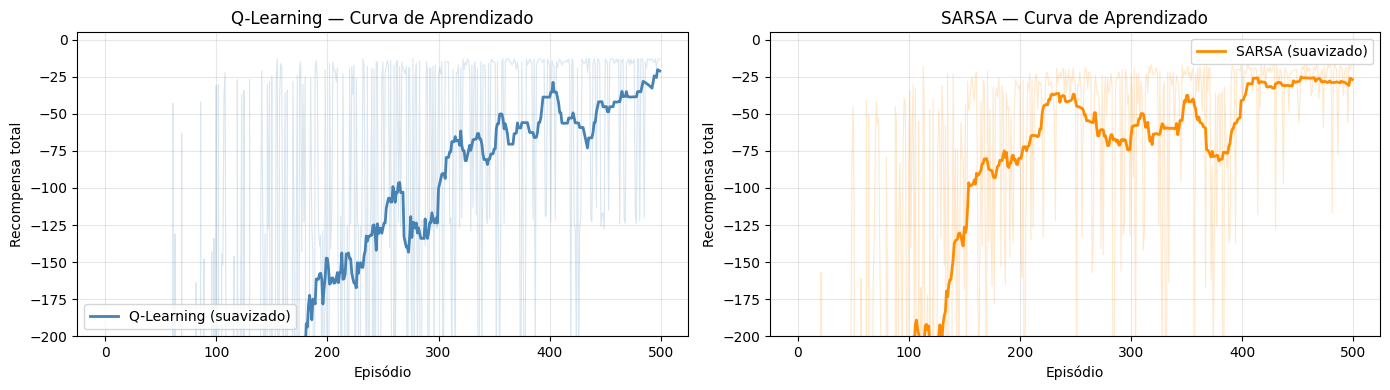

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, result, label, color in zip(
    axes,
    [result_ql, result_sarsa],
    ["Q-Learning", "SARSA"],
    ["steelblue", "darkorange"]
):
    rewards = result.episode_rewards
    ax.plot(rewards, color=color, alpha=0.2, linewidth=0.8)
    ax.plot(smooth(rewards, window=30), color=color, linewidth=2, label=f"{label} (suavizado)")
    ax.set_xlabel("Episódio")
    ax.set_ylabel("Recompensa total")
    ax.set_title(f"{label} — Curva de Aprendizado")
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-200, 5)

plt.tight_layout()
plt.show()

## Políticas Aprendidas

Após o treinamento, extraímos a **política gulosa** de cada Q-table e exibimos a seta correspondente à melhor ação em cada célula do grid.

Observe:
- **Q-Learning**: rota direta pela beira do penhasco (linha 3) — política ótima global
- **SARSA**: rota por cima (linhas 2 ou 1) — política mais segura, subótima mas robusta

In [6]:
print("=== Política Q-Learning ===")
env_ql = CliffWalking()
env_ql.render_policy(result_ql.q_table)

print("=== Política SARSA ===")
env_sarsa = CliffWalking()
env_sarsa.render_policy(result_sarsa.q_table)

=== Política Q-Learning ===
 →  →  →  ↓  ↓  ↓  →  →  →  →  →  ↓ 
 →  →  →  →  →  →  →  →  →  →  →  ↓ 
 →  →  →  →  →  →  →  →  →  →  →  ↓ 
 ↑  C  C  C  C  C  C  C  C  C  C  G 

=== Política SARSA ===
 →  →  →  →  →  →  →  →  →  →  →  ↓ 
 →  ↑  ↑  ↑  ↑  ↑  ↑  →  ↑  ↑  →  ↓ 
 ↑  ←  ↑  →  ↑  ↑  ↑  ↑  ↑  →  →  ↓ 
 ↑  C  C  C  C  C  C  C  C  C  C  G 



## Mapa de Calor do Q-Table

Visualizamos o **valor máximo** Q(s, a*) para cada estado — equivalente à função V(s) extraída da Q-table. Células mais claras têm maior valor esperado.

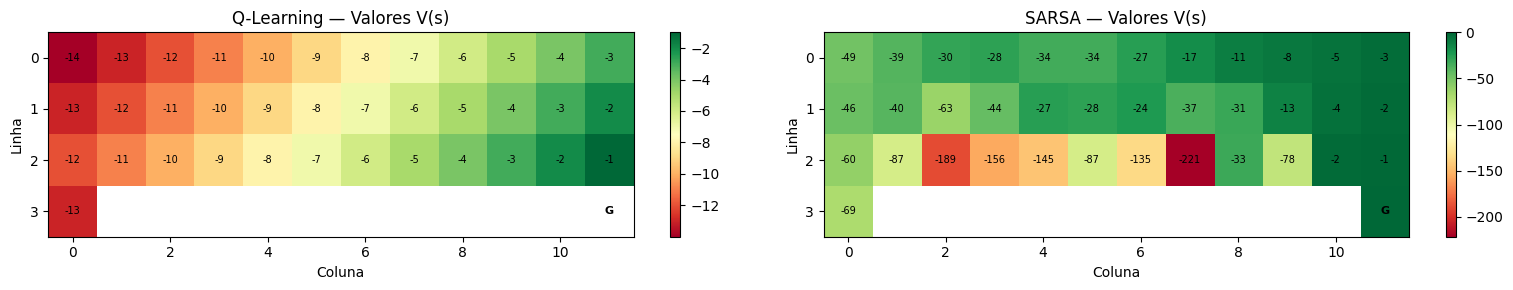

In [7]:
from structures.problems.cliff_walking import CliffState, _ALL_ACTIONS

def build_value_grid(result, rows=4, cols=12):
    """Constrói uma matriz com max_a Q(s,a) para cada estado."""
    grid = np.full((rows, cols), np.nan)
    for r in range(rows):
        for c in range(cols):
            s = CliffState(r, c)
            if s in result.q_table:
                grid[r, c] = max(result.q_table[s].get(a, 0.0) for a in _ALL_ACTIONS)
    return grid

fig, axes = plt.subplots(1, 2, figsize=(16, 3))

for ax, result, title in zip(
    axes,
    [result_ql, result_sarsa],
    ["Q-Learning — Valores V(s)", "SARSA — Valores V(s)"]
):
    grid = build_value_grid(result)
    im = ax.imshow(grid, cmap="RdYlGn", aspect="auto")
    plt.colorbar(im, ax=ax)

    # Rótulos das células
    for r in range(4):
        for c in range(12):
            s = CliffState(r, c)
            if s == CliffWalking.GOAL:
                ax.text(c, r, "G", ha="center", va="center", fontsize=8, fontweight="bold")
            elif s in CliffWalking.CLIFF:
                ax.text(c, r, "C", ha="center", va="center", fontsize=7, color="white")
            elif not np.isnan(grid[r, c]):
                ax.text(c, r, f"{grid[r,c]:.0f}", ha="center", va="center", fontsize=7)

    ax.set_title(title)
    ax.set_xlabel("Coluna")
    ax.set_ylabel("Linha")

plt.tight_layout()
plt.show()

## Avaliação da Política Aprendida

Avaliamos a política **puramente gulosa** (sem exploração ε) extraída de cada Q-table em 100 episódios independentes. Isso mede a qualidade real da política aprendida, separada do processo de exploração.

In [8]:
env_eval = CliffWalking()

mean_ql, std_ql = evaluate_policy(env_eval, result_ql, episodes=100, seed=0)
mean_sarsa, std_sarsa = evaluate_policy(env_eval, result_sarsa, episodes=100, seed=0)

print("Avaliação (política gulosa, 100 episódios):")
print(f"  Q-Learning: média = {mean_ql:.2f} ± {std_ql:.2f}")
print(f"  SARSA:      média = {mean_sarsa:.2f} ± {std_sarsa:.2f}")
print()
print("Interpretação:")
print("  Rota ótima (beira do penhasco):    recompensa ≈ -13")
print("  Rota segura (por cima):            recompensa ≈ -17")

Avaliação (política gulosa, 100 episódios):
  Q-Learning: média = -13.00 ± 0.00
  SARSA:      média = -17.00 ± 0.00

Interpretação:
  Rota ótima (beira do penhasco):    recompensa ≈ -13
  Rota segura (por cima):            recompensa ≈ -17


## Comparação e Conclusões

| | Q-Learning | SARSA |
|---|---|---|
| **Tipo** | Off-policy | On-policy |
| **Atualização** | max Q(s',·) | Q(s',a') |
| **Política aprendida** | Ótima global | Conservadora |
| **Rota no Cliff** | Beira do penhasco | Por cima |
| **Recompensa (avaliação)** | ≈ −13 | ≈ −17 |
| **Recompensa (treino)** | Menor (cai no penhasco) | Maior (evita risco) |

### Insight Chave

O Cliff Walking revela um trade-off fundamental do RL:

- **Q-Learning** converge para a política **globalmente ótima**, mas paga um custo de exploração maior durante o treinamento
- **SARSA** aprende uma política **segura em relação à exploração atual**, gerando melhor desempenho *durante o treino*, mas obtendo uma política final subótima

Na prática, se o custo das ações de exploração é alto (ex: robótica real), SARSA pode ser preferível. Se a exploração é barata (ex: simulação), Q-Learning tende a ser melhor.